# Experiment 2: Preprocessing & Data Leakage

- **Dataset:** Titanic
- **Target:** Survived
- **Goal:** Show data leakage from incorrect preprocessing.

## 1. Data Leakage
Leakage happens when test data info leaks into training. E.g., computing mean/mode before train/test split.

## 2. Setup

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

import kagglehub
import os
path = kagglehub.dataset_download('yasserh/titanic-dataset')
df = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

X = df[num_cols + cat_cols]
y = df['Survived']

print(f"X shape: {X.shape}")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f'\n--- {name} ---')
    print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score:  {f1_score(y_true, y_pred):.4f}')
    print(f'ROC AUC:   {roc_auc_score(y_true, y_prob):.4f}')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'{name} - Confusion Matrix')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_prob):.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title(f'{name} - ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()


/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X shape: (891, 7)


*Excluding high-cardinality features like Name and Ticket for simplicity.*

## 3. Flawed Pipeline (Leakage)

In [2]:
def get_preprocessor():
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

# WRONG: Preprocessing whole dataset
X_leak = get_preprocessor().fit_transform(X)
X_train_L, X_test_L, y_train_L, y_test_L = train_test_split(X_leak, y, test_size=0.3, random_state=42)

model_leak = LogisticRegression()
model_leak.fit(X_train_L, y_train_L)
preds_leak = model_leak.predict(X_test_L)


--- Leaky Pipeline (Preprocessing) ---
Accuracy:  0.8097
Precision: 0.7941
Recall:    0.7297
F1-Score:  0.7606
ROC AUC:   0.8800


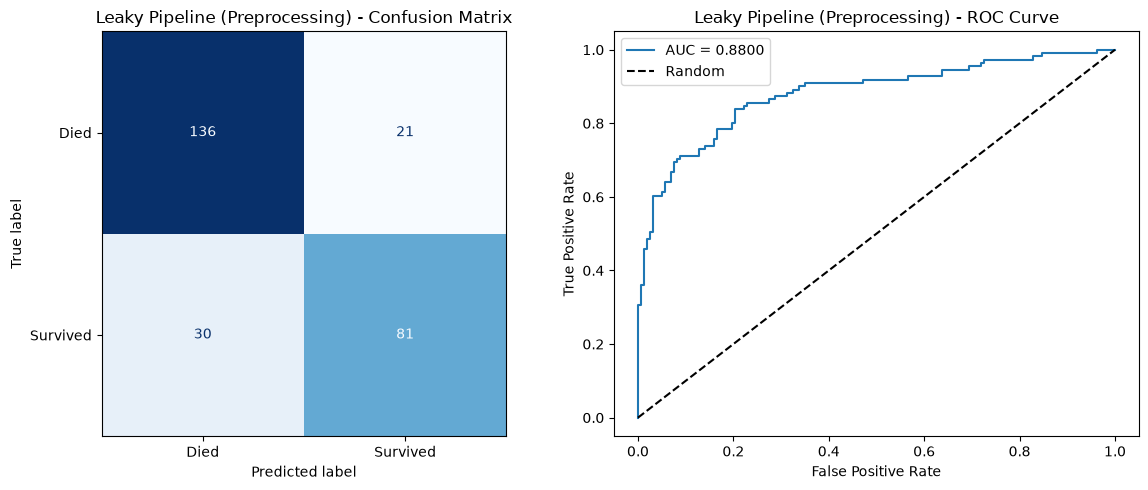

In [3]:
evaluate_model('Leaky Pipeline (Preprocessing)', y_test_L, preds_leak, model_leak.predict_proba(X_test_L)[:, 1])

**Issue:** `fit_transform` on the whole dataset leaks test data distribution into the model.

## 4. Correct Pipeline (No Leakage)

In [4]:
# CORRECT: Split first, then preprocess
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipe = Pipeline([('prep', get_preprocessor()), ('model', LogisticRegression())])
pipe.fit(X_train, y_train)
preds_correct = pipe.predict(X_test)


--- Correct Pipeline ---
Accuracy:  0.8097
Precision: 0.7941
Recall:    0.7297
F1-Score:  0.7606
ROC AUC:   0.8798


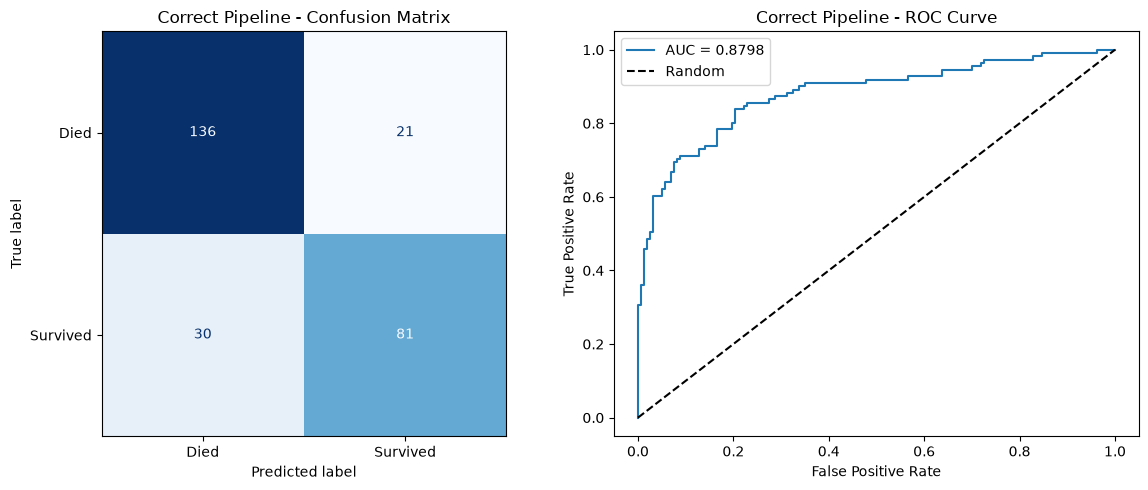

In [5]:
evaluate_model('Correct Pipeline', y_test, preds_correct, pipe.predict_proba(X_test)[:, 1])

## 5. Compare Results

In [6]:
print(f"Leaky Age Mean (Full Data): {X['Age'].mean():.2f}")
print(f"Correct Age Mean (Train Only): {X_train['Age'].mean():.2f}")

Leaky Age Mean (Full Data): 29.70
Correct Age Mean (Train Only): 29.26


## 6. Why it matters
Leakage artificially inflates metrics but fails in real-world deployment.

## 7. Leakage Example 2: Imputing before split


--- Imputation Leak ---
Accuracy:  0.8097
Precision: 0.7941
Recall:    0.7297
F1-Score:  0.7606
ROC AUC:   0.8798


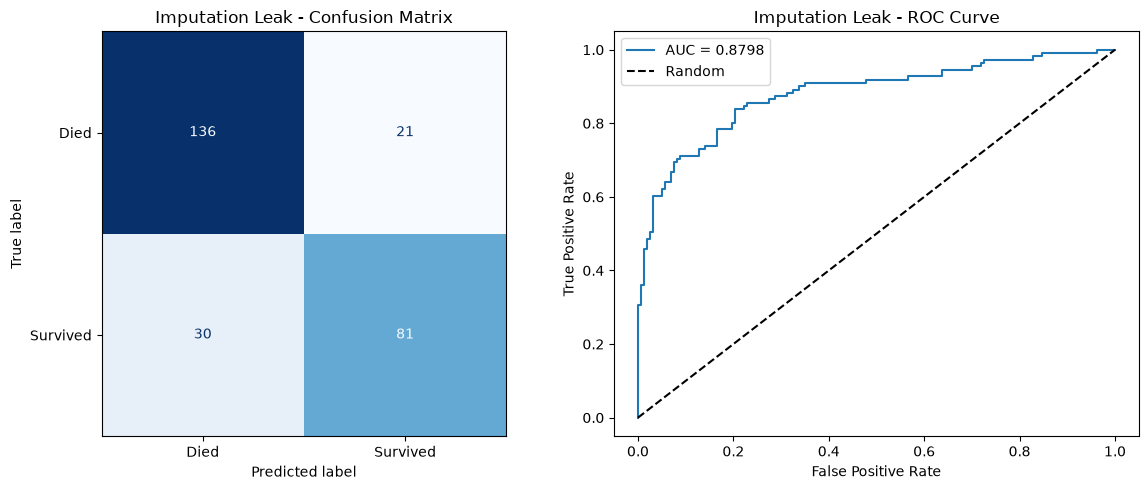

In [7]:
# FLAW 2: Imputing on full data before split
X_imp = X.fillna(X.median(numeric_only=True))
for col in cat_cols:
    X_imp[col] = X_imp[col].fillna(X_imp[col].mode()[0])

X_tr_imp, X_te_imp, y_tr_imp, y_te_imp = train_test_split(X_imp, y, test_size=0.3, random_state=42)

pipe_imp = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])),
    ('model', LogisticRegression())
])
pipe_imp.fit(X_tr_imp, y_tr_imp)
evaluate_model('Imputation Leak', y_te_imp, pipe_imp.predict(X_te_imp), pipe_imp.predict_proba(X_te_imp)[:, 1])


## 8. Leakage Example 3: Target Leakage
Using target labels to create features before splitting is severe leakage.


--- Target Leak ---
Accuracy:  0.9888
Precision: 1.0000
Recall:    0.9730
F1-Score:  0.9863
ROC AUC:   0.9999


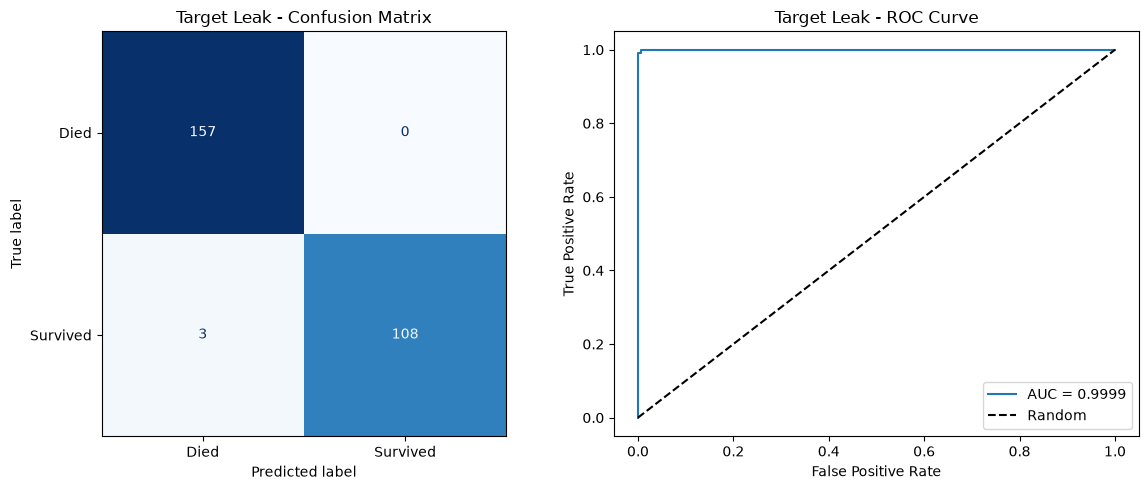

In [8]:
# FLAW 3: Target Leakage (creating feature using target before split)
X_tgt_leak = X.copy()
X_tgt_leak['Ticket_Surv_Rate'] = df.groupby('Ticket')['Survived'].transform('mean')

X_tr_tl, X_te_tl, y_tr_tl, y_te_tl = train_test_split(X_tgt_leak, y, test_size=0.3, random_state=42)

pipe_tl = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), num_cols + ['Ticket_Surv_Rate']),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])),
    ('model', LogisticRegression())
])
pipe_tl.fit(X_tr_tl, y_tr_tl)
evaluate_model('Target Leak', y_te_tl, pipe_tl.predict(X_te_tl), pipe_tl.predict_proba(X_te_tl)[:, 1])


## 9. Summary
- Always split data **before** any preprocessing.
- Fit scalers/imputers on **train data only**.